In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

In [2]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train Data:", len(train_dataset))
print("Test Data:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]

Train Data: 60000
Test Data: 10000


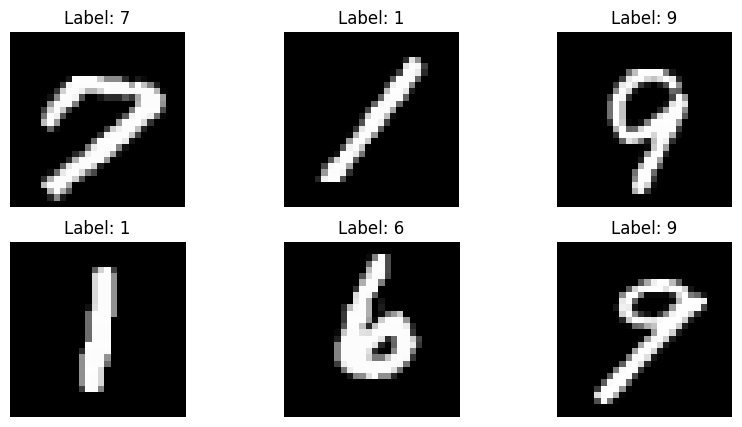

In [3]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.title(f"Label: {labels[i].item()}")

    plt.axis("off")

plt.show()

In [4]:
model1 = nn.Sequential(

    nn.Flatten(),

    nn.Linear(28*28, 128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.ReLU(),

    nn.Linear(64, 10)
)

print(model1)

criterion1 = nn.CrossEntropyLoss()

optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
train_losses1 = []
accuracies1 = []

epochs = 10

print("Training Experiment 1...\n")

for epoch in range(epochs):

    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:

        outputs = model1(images)

        loss = criterion1(outputs, labels)

        optimizer1.zero_grad()

        loss.backward()

        optimizer1.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = correct / total

    train_losses1.append(running_loss)
    accuracies1.append(accuracy)

    print(f"Epoch {epoch+1} | Loss: {running_loss:.4f} | Accuracy: {accuracy:.4f}")
    model1.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model1(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_acc1 = correct / total

print("Experiment 1 Test Accuracy:", test_acc1)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)
Training Experiment 1...

Epoch 1 | Loss: 328.8314 | Accuracy: 0.9015
Epoch 2 | Loss: 140.1077 | Accuracy: 0.9561
Epoch 3 | Loss: 93.7852 | Accuracy: 0.9700
Epoch 4 | Loss: 69.6806 | Accuracy: 0.9775
Epoch 5 | Loss: 54.8828 | Accuracy: 0.9817
Epoch 6 | Loss: 40.9770 | Accuracy: 0.9859
Epoch 7 | Loss: 34.0482 | Accuracy: 0.9884
Epoch 8 | Loss: 27.8675 | Accuracy: 0.9908
Epoch 9 | Loss: 24.2197 | Accuracy: 0.9919
Epoch 10 | Loss: 19.8544 | Accuracy: 0.9929
Experiment 1 Test Accuracy: 0.977


In [5]:
model2 = nn.Sequential(

    nn.Flatten(),

    nn.Linear(28*28, 256),
    nn.Tanh(),

    nn.Linear(256, 128),
    nn.Tanh(),

    nn.Linear(128, 10)
)

print(model2)
criterion2 = nn.CrossEntropyLoss()

optimizer2 = optim.Adam(model2.parameters(), lr=0.001)
train_losses2 = []
accuracies2 = []

epochs = 5

print("Training Experiment 2...\n")

for epoch in range(epochs):

    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:

        outputs = model2(images)

        loss = criterion2(outputs, labels)

        optimizer2.zero_grad()

        loss.backward()

        optimizer2.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = correct / total

    train_losses2.append(running_loss)
    accuracies2.append(accuracy)

    print(f"Epoch {epoch+1} | Loss: {running_loss:.4f} | Accuracy: {accuracy:.4f}")
    model2.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model2(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_acc2 = correct / total

print("Experiment 2 Test Accuracy:", test_acc2)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Tanh()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): Tanh()
  (5): Linear(in_features=128, out_features=10, bias=True)
)
Training Experiment 2...

Epoch 1 | Loss: 272.0297 | Accuracy: 0.9155
Epoch 2 | Loss: 119.7313 | Accuracy: 0.9612
Epoch 3 | Loss: 78.5928 | Accuracy: 0.9740
Epoch 4 | Loss: 57.5027 | Accuracy: 0.9810
Epoch 5 | Loss: 42.1646 | Accuracy: 0.9859
Experiment 2 Test Accuracy: 0.9763


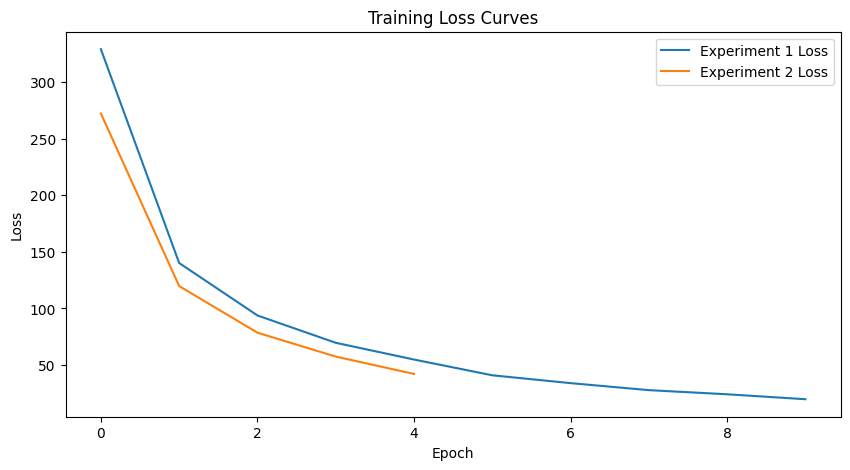

In [6]:
plt.figure(figsize=(10,5))

plt.plot(train_losses1, label="Experiment 1 Loss")

plt.plot(train_losses2, label="Experiment 2 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Curves")

plt.legend()

plt.show()

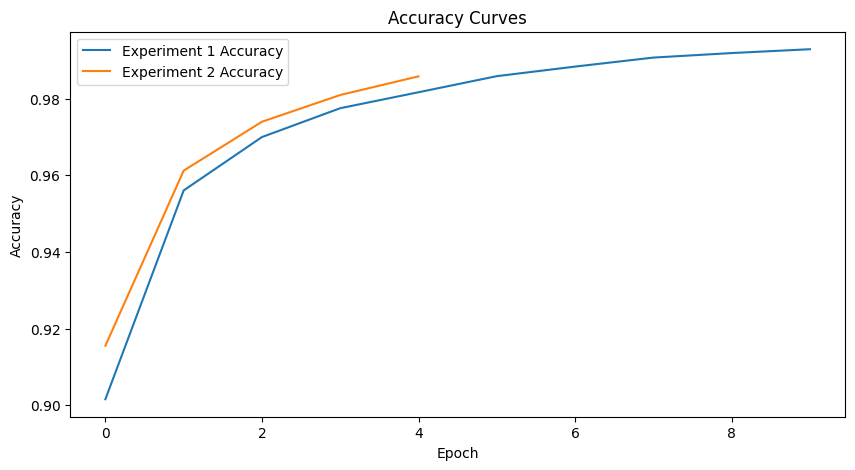

In [7]:
plt.figure(figsize=(10,5))

plt.plot(accuracies1, label="Experiment 1 Accuracy")

plt.plot(accuracies2, label="Experiment 2 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curves")

plt.legend()

plt.show()

In [8]:
print("\n========== RESULTS ==========")

print(f"Experiment 1 Accuracy: {test_acc1:.4f}")

print(f"Experiment 2 Accuracy: {test_acc2:.4f}")

if test_acc1 > test_acc2:
    print("\nExperiment 1 performed better.")

else:
    print("\nExperiment 2 performed better.")


========== RESULTS ==========
Experiment 1 Accuracy: 0.9770
Experiment 2 Accuracy: 0.9763

Experiment 1 performed better.
